# Entrena tu primera red neuronal para clasificación de imágenes desde 0


Hoy vamos a construir, paso a paso, un clasificador de imágenes que distingue entre **piedra 🪨, papel 📄 y tijeras ✂️**. Lo haremos 3 veces, cada vez con un modelo más poderoso:

| # | Modelo | Idea clave |
|---|--------|-----------|
| 1 | **MLP** (perceptrón multicapa) | La red neuronal más simple posible |
| 2 | **CNN LeNet-5** | Redes que "ven" patrones espaciales (1998, Yann LeCun) |
| 3 | **Transfer learning (ResNet-18)** | Reutilizar una red ya entrenada con millones de imágenes |

### El pipeline que repetiremos siempre

En *deep learning*, entrenar **cualquier** modelo sigue las mismas etapas. Memoriza este flujo, porque lo usarás toda tu carrera:

```
Datos →  Preprocesamiento →  DataLoader →  Modelo → Loss → Optimizer → Entrenar → Evaluar
```

> 💡 **Stack:** PyTorch · torchvision · timm · NumPy · scikit-learn · matplotlib


## Setup: librerías, semilla y dispositivo

Antes de empezar, tres cosas:

1. **Importar** las librerías que usaremos.
2. **Fijar una semilla** (*seed*): las redes neuronales usan números aleatorios (pesos iniciales, orden de los datos...). Fijar la semilla hace que todos obtengamos resultados parecidos.
3. **Elegir el dispositivo**: si tienes GPU (NVIDIA → `cuda`, Mac → `mps`) el entrenamiento será mucho más rápido. Si no, usamos la CPU.


In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image

# Semilla para que los resultados sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


if torch.backends.mps.is_available():      # GPU de Apple (Mac M1/M2/M3...)
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():            # GPU NVIDIA
    DEVICE = torch.device("cuda")
else:                                      # CPU
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__} | Entrenaremos en: {DEVICE}")

PyTorch 2.14.0 | Entrenaremos en: mps


In [2]:
# from google.colab import drive

# drive.mount('/content/drive')

## Conoce tus datos

**Regla de oro:** antes de entrenar nada, *mira* tus datos. ¿Cuántas imágenes hay? ¿Las clases están balanceadas? ¿Cómo se ven?

Nuestro dataset está organizado en carpetas, una por clase:

```
data/rock-paper-scissors/
├── rock/      ← imágenes de piedra
├── paper/     ← imágenes de papel
└── scissors/  ← imágenes de tijeras
```

Esta estructura de "una carpeta por clase" es un estándar, y PyTorch la entiende directamente.


In [3]:
# DATA_DIR = Path("/content/drive/MyDrive/codiGO_by_Tecsup/workshop_2026_06_09/data/rock-paper-scissors")
DATA_DIR = Path("/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors")

for carpeta in sorted(DATA_DIR.iterdir()):
    if carpeta.is_dir():
        n_imagenes = len(list(carpeta.glob("*.png")))
        print(f"{carpeta.name:>10s} → {n_imagenes} imágenes")


     paper → 712 imágenes
      rock → 726 imágenes
  scissors → 750 imágenes


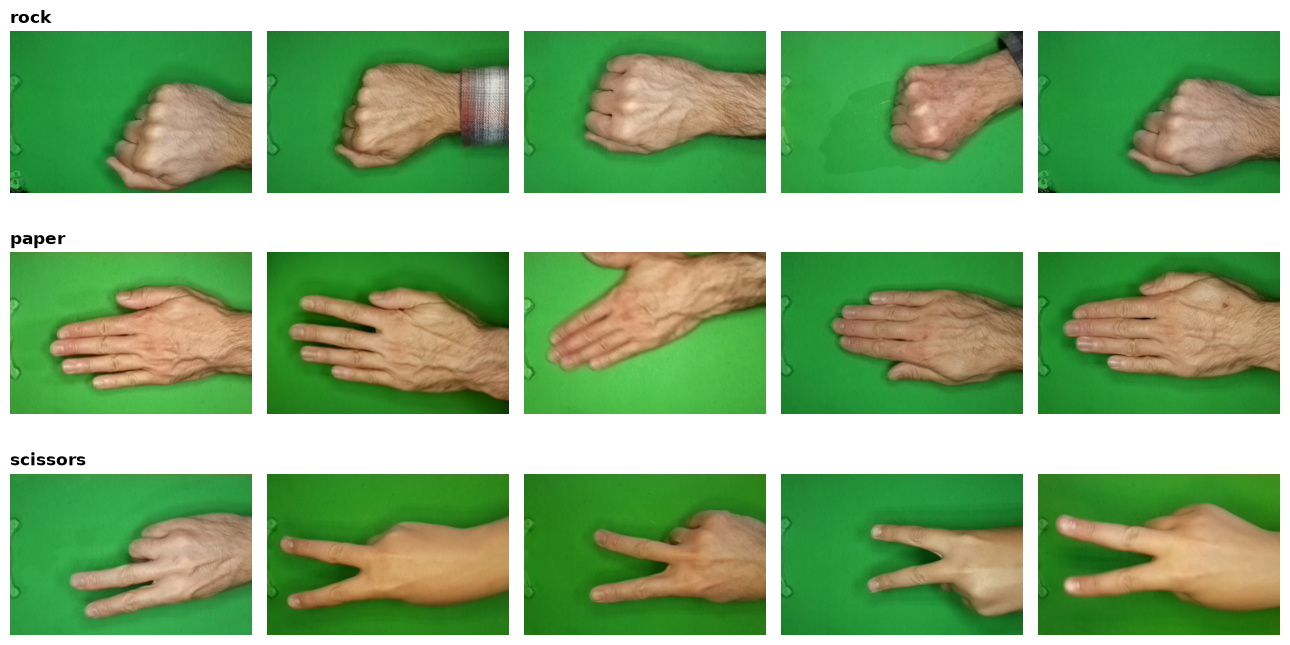

In [5]:
# Veamos 5 ejemplos de cada clase
clases_carpetas = ["rock", "paper", "scissors"]

fig, axes = plt.subplots(3, 5, figsize=(13, 7))
for fila, clase in enumerate(clases_carpetas):
    rutas = sorted((DATA_DIR / clase).glob("*.png"))[:5]
    for col, ruta in enumerate(rutas):
        axes[fila, col].imshow(Image.open(ruta))
        axes[fila, col].axis("off")
        if col == 0:
            axes[fila, col].set_title(clase, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()


### ¿Qué "ve" la computadora?

Para nosotros esto son manos; para la computadora, cada imagen es una **tabla de números**:

- Cada imagen mide **300 × 200 píxeles**.
- Cada píxel tiene **3 números** (Rojo, Verde, Azul), entre 0 y 255.
- Total: 300 × 200 × 3 = **180,000 números por imagen**.

Una red neuronal es una máquina que recibe esos números y aprende a transformarlos en una respuesta: *"esto es papel"*.


In [7]:
300 * 200 * 3

180000

## Preprocesamiento: preparar las imágenes

Las imágenes crudas no entran directo al modelo. Les aplicamos **transformaciones**:

| Transformación | ¿Para qué? |
|----------------|-----------|
| `Resize(64×64)` | Reducir el tamaño → menos números → entrenamiento más rápido |
| `ToTensor()` | Convertir la imagen a un *tensor* de PyTorch, con valores entre 0 y 1 |
| `Normalize(...)` | Centrar los valores alrededor de 0 → la red aprende más fácil |

> 💡 **¿Por qué normalizar?** Las redes neuronales aprenden mejor cuando los números de entrada son pequeños y están centrados en 0 (aprox. entre -1 y 1) en lugar de ir de 0 a 255.


In [8]:
IMG_SIZE_MLP = 32

transform_mlp = transforms.Compose([
    transforms.Resize((IMG_SIZE_MLP, IMG_SIZE_MLP)),
    transforms.ToTensor(),                       # imagen → tensor con valores [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # [0, 1] → [-1, 1]
                         std=[0.5, 0.5, 0.5]),
])

print(transform_mlp)


Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## Dataset y DataLoader: servir los datos al modelo

Dos piezas clave de PyTorch:

- **`Dataset`** → sabe *dónde* están los datos y cómo leer uno. Usamos `ImageFolder`, que asigna la etiqueta según la carpeta (rock=1... ¡lo decide alfabéticamente!).
- **`DataLoader`** → entrega los datos en **batches** (grupos, p. ej. de 64) y los **mezcla** (*shuffle*) en cada época.

### ¿Por qué dividir los datos?

| Split | % | ¿Para qué? |
|-------|---|-----------|
| **Train** | 70% | El modelo aprende con estas imágenes |
| **Validation** | 15% | Vigilamos el aprendizaje durante el entrenamiento |
| **Test** | 15% | Examen final: imágenes que el modelo **jamás vio** |

> Es como estudiar para un examen: practicas con unos ejercicios (train), te autoevalúas con otros (val), y el profesor te toma el examen con preguntas nuevas (test).


In [ ]:
BATCH_SIZE = 64

def crear_dataloaders(transform, batch_size=BATCH_SIZE):
    """Crea los DataLoaders de train/val/test con un transform dado.

    Usamos siempre la misma semilla, así los 3 modelos se evalúan
    exactamente con las mismas imágenes de test (comparación justa).
    """
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    generador = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test], generator=generador
    )

    # test_data_imgs = [dataset.imgs[x] for x in test_ds.indices]

    # print(test_data_imgs)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    test_dl = DataLoader(test_ds, batch_size=batch_size)
    return train_dl, val_dl, test_dl, dataset.classes


train_dl_mlp, val_dl_mlp, test_dl_mlp, CLASES = crear_dataloaders(transform_mlp)

print(f"Clases (orden alfabético): {CLASES}")
print(f"Train: {len(train_dl_mlp.dataset)} | Val: {len(val_dl_mlp.dataset)} | Test: {len(test_dl_mlp.dataset)}")

[('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/scissors/3n4i3lKB3nZOpDVv.png', 2), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/B08mrGoODd5gGTvu.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/2tDgPZGqbrw95j39.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/LqxEdPczGbYd9Zlu.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/OdfDTwgPVdW9XbE7.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/Qxx5l8WCNBjMb5xI.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/2PAcPusQ59xIMfiw.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/paper/uoYuyEHvVLrOOmqW.png', 0), ('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/d

Forma del batch de imágenes: torch.Size([64, 3, 32, 32])  ← [batch, canales, alto, ancho]
Forma del batch de etiquetas: torch.Size([64])
Primeras etiquetas: [1, 2, 0, 2, 2, 1, 0, 2]


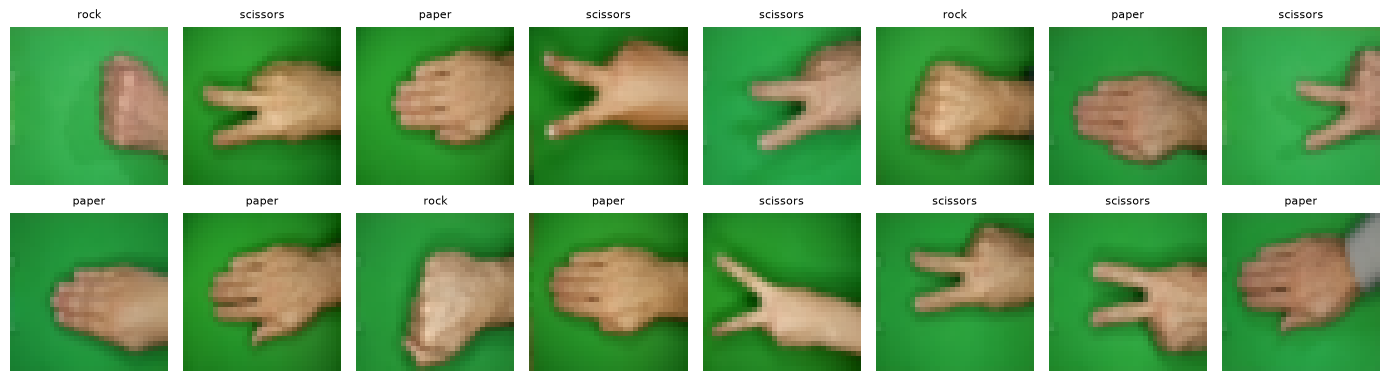

In [18]:
# Saquemos UN batch para ver qué recibe el modelo
imagenes, etiquetas = next(iter(train_dl_mlp))

print(f"Forma del batch de imágenes: {imagenes.shape}  ← [batch, canales, alto, ancho]")
print(f"Forma del batch de etiquetas: {etiquetas.shape}")
print(f"Primeras etiquetas: {etiquetas[:8].tolist()}")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, etiqueta in zip(axes.flat, imagenes, etiquetas):
    img = img * 0.5 + 0.5                  # deshacemos la normalización para visualizar
    ax.imshow(img.permute(1, 2, 0))        # [canales, alto, ancho] → [alto, ancho, canales]
    ax.set_title(CLASES[etiqueta], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Modelo 1: MLP (perceptrón multicapa)

Nuestra primera red neuronal. Un MLP solo entiende **listas planas de números**, así que:

1. **`Flatten`**: aplana la imagen de 3×64×64 a una lista de **12,288 números**.
2. **Capas `Linear`**: cada neurona combina todos los números de entrada con sus propios "pesos" (los pesos son lo que la red *aprende*).
3. **`ReLU`**: una función simple (si es negativo → 0) que le permite a la red aprender relaciones no lineales.
4. **Capa de salida**: 3 números, uno por clase. El más alto = la predicción.

```
imagen 3×32×32 → Flatten → 3,072 → [512 neuronas] → [128 neuronas] → [3 salidas]
```

⚠️ **Problema del MLP:** al aplanar, la imagen pierde su estructura espacial — la red no sabe qué píxeles eran vecinos. Es como leer un libro con todas las letras en orden aleatorio.


In [25]:
class MLP(nn.Module):
    def __init__(self, num_clases=3):
        super().__init__()
        self.red = nn.Sequential(
            nn.Flatten(),                            # 3×32×32 → 3,072
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_clases),              # 3 salidas: una por clase
        )

    def forward(self, x):
        return self.red(x)


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


modelo_mlp = MLP().to(DEVICE)
print(modelo_mlp)
print(f"\nParámetros entrenables: {contar_parametros(modelo_mlp):,}")

MLP(
  (red): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=3, bias=True)
  )
)

Parámetros entrenables: 1,639,427


## Loss y Optimizer: ¿cómo aprende una red?

Una red empieza con pesos **aleatorios** (predice cualquier cosa). Aprender = ajustar esos pesos. Para eso necesitamos dos piezas:

- **Loss (función de pérdida)** — mide *qué tan equivocada* está la red. Si predice "tijeras" y era "piedra", la loss es alta. Usamos `CrossEntropyLoss`, la estándar para clasificación.
- **Optimizer (optimizador)** — decide *cómo corregir* los pesos para que la loss baje, usando los gradientes (la dirección de mejora). Usamos `Adam`, el más popular.

> **Analogía:** estás en una montaña con niebla (la loss es tu altura) y quieres bajar al valle. El gradiente te dice hacia dónde está la bajada; el optimizer decide qué tan grandes son tus pasos (el *learning rate*).


In [26]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo_mlp.parameters(), lr=1e-3)

print(criterio)
print(optimizador)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Entrenar: el bucle de entrenamiento

El corazón del deep learning. En cada **época** (una pasada completa por los datos de train), para cada batch:

1. **Forward** → la red predice.
2. **Loss** → medimos el error.
3. **Backward** → calculamos los gradientes (`loss.backward()`).
4. **Step** → el optimizer ajusta los pesos (`optimizador.step()`).

Escribiremos estas funciones **una sola vez** y las reutilizaremos para los 3 modelos.


In [21]:
def entrenar_una_epoca(modelo, dataloader, criterio, optimizador):
    """Una pasada completa por los datos de entrenamiento."""
    modelo.train()                          # modo entrenamiento
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)

        optimizador.zero_grad()             # 0. limpiar gradientes anteriores
        logits = modelo(imagenes)           # 1. forward: la red predice
        perdida = criterio(logits, etiquetas)  # 2. loss: ¿qué tan mal?
        perdida.backward()                  # 3. backward: calcular gradientes
        optimizador.step()                  # 4. step: ajustar pesos

        perdida_total += perdida.item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n


@torch.no_grad()                            # aquí NO aprendemos, solo medimos
def evaluar(modelo, dataloader, criterio):
    """Mide loss y accuracy sin modificar el modelo."""
    modelo.eval()                           # modo evaluación
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)
        logits = modelo(imagenes)
        perdida_total += criterio(logits, etiquetas).item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n


def fit(modelo, train_dl, val_dl, criterio, optimizador, epocas):
    """Entrena el modelo y guarda el historial de métricas."""
    historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoca in range(1, epocas + 1):
        train_loss, train_acc = entrenar_una_epoca(modelo, train_dl, criterio, optimizador)
        val_loss, val_acc = evaluar(modelo, val_dl, criterio)

        historial["train_loss"].append(train_loss)
        historial["train_acc"].append(train_acc)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)

        print(f"Época {epoca}/{epocas} | "
              f"train loss: {train_loss:.4f}, acc: {train_acc:.2%} | "
              f"val loss: {val_loss:.4f}, acc: {val_acc:.2%}")

    return historial

In [31]:
EPOCAS = 20

modelo_mlp = MLP().to(DEVICE)
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo_mlp.parameters(), lr=1e-3)

historial_mlp = fit(modelo_mlp, train_dl_mlp, val_dl_mlp, criterio, optimizador, EPOCAS)

Época 1/20 | train loss: 0.8459, acc: 60.81% | val loss: 0.5821, acc: 76.22%
Época 2/20 | train loss: 0.4848, acc: 83.21% | val loss: 0.3654, acc: 88.41%
Época 3/20 | train loss: 0.2944, acc: 90.20% | val loss: 0.2843, acc: 90.24%
Época 4/20 | train loss: 0.2194, acc: 91.97% | val loss: 0.2512, acc: 92.07%
Época 5/20 | train loss: 0.1542, acc: 95.36% | val loss: 0.2129, acc: 92.99%
Época 6/20 | train loss: 0.1381, acc: 95.69% | val loss: 0.2391, acc: 90.85%
Época 7/20 | train loss: 0.0982, acc: 96.86% | val loss: 0.1696, acc: 93.29%
Época 8/20 | train loss: 0.0700, acc: 97.84% | val loss: 0.1564, acc: 93.90%
Época 9/20 | train loss: 0.0594, acc: 97.91% | val loss: 0.1656, acc: 93.90%
Época 10/20 | train loss: 0.0369, acc: 99.02% | val loss: 0.1596, acc: 94.82%
Época 11/20 | train loss: 0.0382, acc: 98.76% | val loss: 0.1825, acc: 93.90%
Época 12/20 | train loss: 0.0408, acc: 98.76% | val loss: 0.1827, acc: 94.21%
Época 13/20 | train loss: 0.0256, acc: 99.28% | val loss: 0.1572, acc: 95

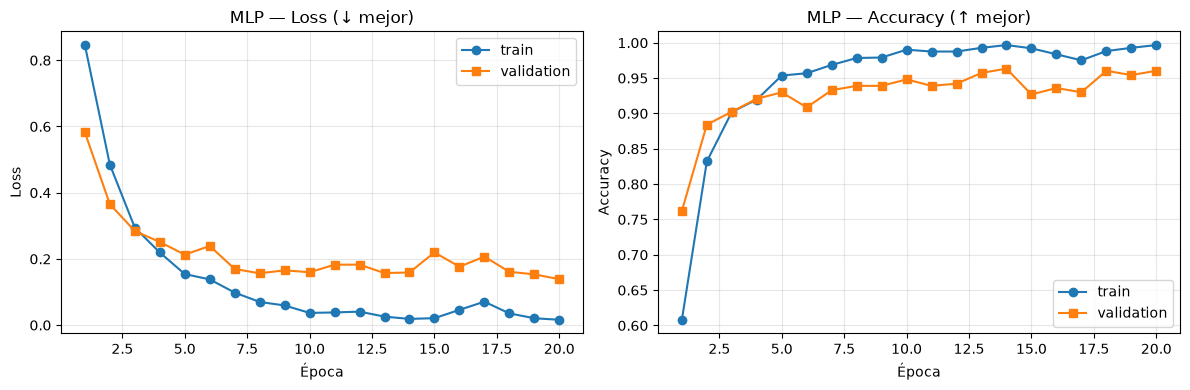

In [32]:
def graficar_historial(historial, titulo):
    """Curvas de loss y accuracy durante el entrenamiento."""
    epocas = range(1, len(historial["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epocas, historial["train_loss"], "o-", label="train")
    ax1.plot(epocas, historial["val_loss"], "s-", label="validation")
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{titulo} — Loss (↓ mejor)"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epocas, historial["train_acc"], "o-", label="train")
    ax2.plot(epocas, historial["val_acc"], "s-", label="validation")
    ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{titulo} — Accuracy (↑ mejor)"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


graficar_historial(historial_mlp, "MLP")

## Modelo 2: CNN LeNet-5

El MLP aplana la imagen y pierde la información espacial. Las **redes convolucionales (CNN)** resuelven esto:

- Una **convolución** desliza pequeños filtros (p. ej. de 5×5 píxeles) sobre la imagen, buscando patrones locales: bordes, esquinas, texturas. *No importa dónde esté la mano en la foto, el filtro la encuentra.*
- El **pooling** reduce el tamaño quedándose con lo más importante de cada zona (resumen).
- Al apilar capas, la red detecta patrones cada vez más complejos: bordes → dedos → mano completa.

Usaremos **LeNet-5** (Yann LeCun, 1998), la CNN que leía códigos postales en los 90 — ¡la abuela de las redes modernas! La adaptamos ligeramente: entrada a color (3 canales) de 32×32, y ReLU + MaxPool en lugar de las funciones originales.

```
3×32×32 → Conv(6 filtros 5×5) → Pool → Conv(16 filtros 5×5) → Pool → Flatten → 120 → 84 → 3
```


In [35]:
IMG_SIZE_CNN = 32

transform_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dl_cnn, val_dl_cnn, test_dl_cnn, _ = crear_dataloaders(transform_cnn)


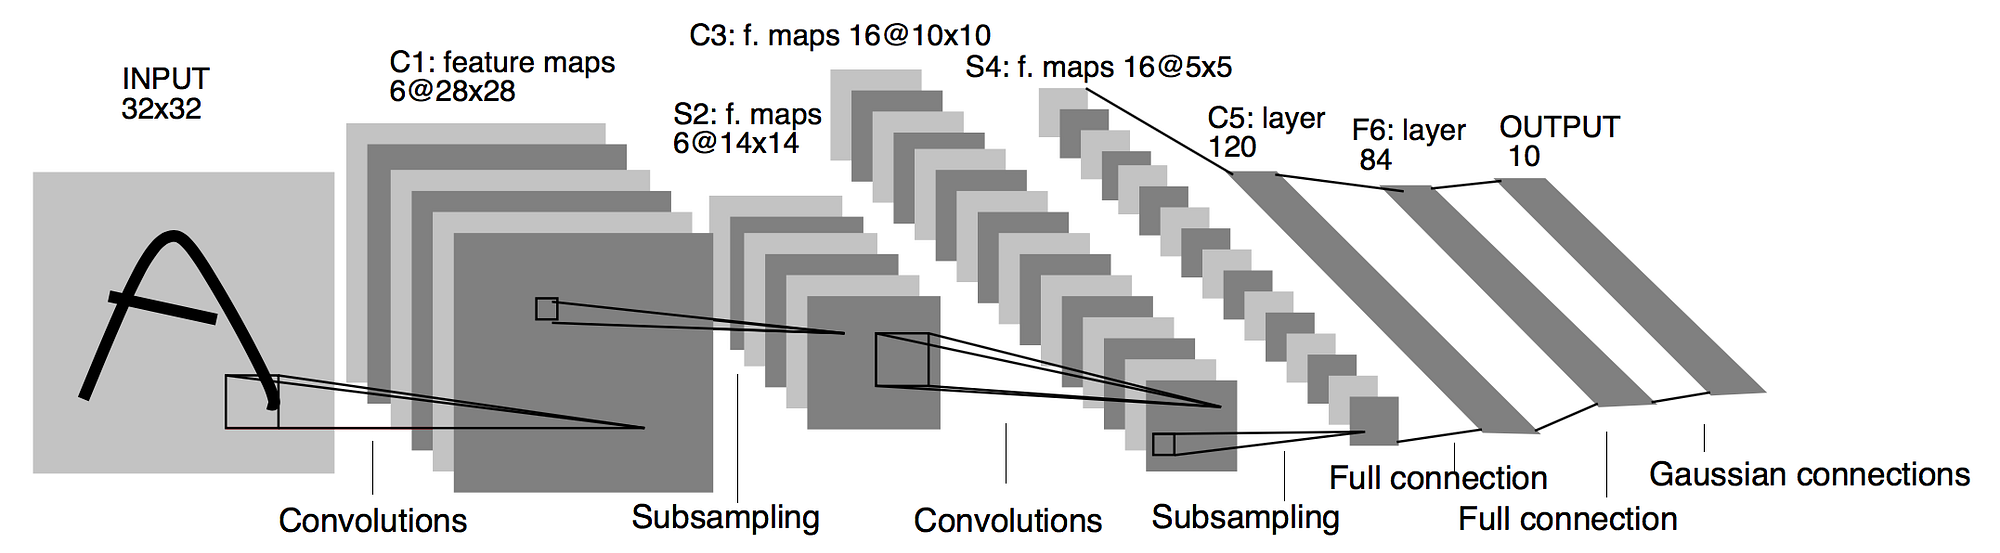

In [33]:
class LeNet5(nn.Module):
    """LeNet-5 (1998) adaptada: entrada RGB 32×32, ReLU y MaxPool."""

    def __init__(self, num_clases=3):
        super().__init__()
        self.extractor = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),    # 3×32×32 → 6×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 6×14×14
            nn.Conv2d(6, 16, kernel_size=5),   # → 16×10×10
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 16×5×5
        )
        self.clasificador = nn.Sequential(
            nn.Flatten(),                      # 16×5×5 → 400
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_clases),
        )

    def forward(self, x):
        x = self.extractor(x)        # las convoluciones "ven" patrones
        return self.clasificador(x)  # las capas lineales deciden la clase


modelo_lenet = LeNet5().to(DEVICE)
print(modelo_lenet)
print(f"\nParámetros entrenables: {contar_parametros(modelo_lenet):,}")
print(f"(El MLP tenía {contar_parametros(modelo_mlp):,} — ¡la CNN es mucho más pequeña!)")

LeNet5(
  (extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=3, bias=True)
  )
)

Parámetros entrenables: 61,411
(El MLP tenía 1,639,427 — ¡la CNN es mucho más pequeña!)


Época 1/20 | train loss: 0.9451, acc: 59.37% | val loss: 0.6166, acc: 82.01%
Época 2/20 | train loss: 0.3900, acc: 87.13% | val loss: 0.3019, acc: 92.07%
Época 3/20 | train loss: 0.1915, acc: 93.40% | val loss: 0.2425, acc: 92.99%
Época 4/20 | train loss: 0.1358, acc: 95.36% | val loss: 0.1900, acc: 95.43%
Época 5/20 | train loss: 0.1070, acc: 96.28% | val loss: 0.1567, acc: 96.65%
Época 6/20 | train loss: 0.0736, acc: 97.58% | val loss: 0.1475, acc: 96.95%
Época 7/20 | train loss: 0.0660, acc: 97.84% | val loss: 0.1254, acc: 97.87%
Época 8/20 | train loss: 0.0768, acc: 97.45% | val loss: 0.1995, acc: 94.51%
Época 9/20 | train loss: 0.0870, acc: 96.73% | val loss: 0.1344, acc: 97.26%
Época 10/20 | train loss: 0.0530, acc: 98.43% | val loss: 0.1050, acc: 98.17%
Época 11/20 | train loss: 0.0363, acc: 99.09% | val loss: 0.1154, acc: 98.48%
Época 12/20 | train loss: 0.0268, acc: 99.22% | val loss: 0.0919, acc: 98.48%
Época 13/20 | train loss: 0.0239, acc: 99.54% | val loss: 0.0943, acc: 98

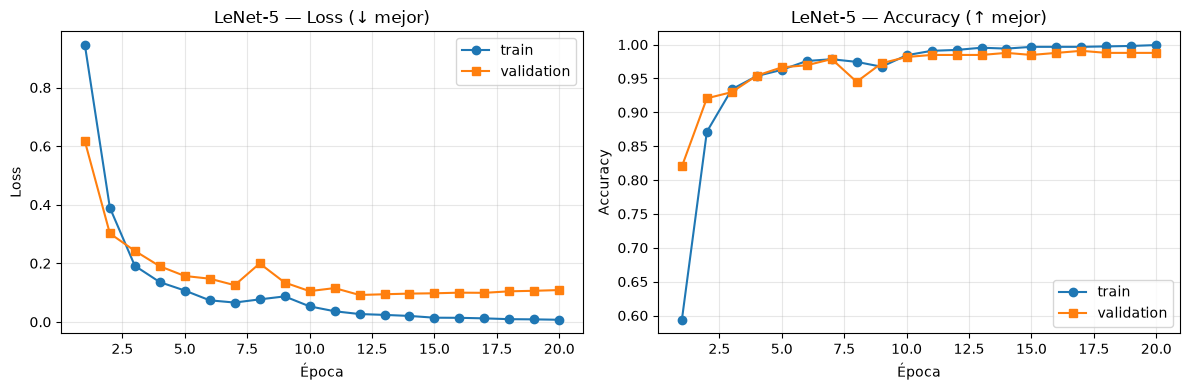

In [36]:
# Mismo pipeline de siempre: loss → optimizer → entrenar
optimizador_lenet = torch.optim.Adam(modelo_lenet.parameters(), lr=1e-3)

historial_lenet = fit(modelo_lenet, train_dl_cnn, val_dl_cnn, criterio, optimizador_lenet, EPOCAS)
graficar_historial(historial_lenet, "LeNet-5")

## Modelo 3: Transfer learning con ResNet-18

Hasta ahora nuestras redes aprenden a "ver" **desde cero** con ~2,000 imágenes. Pero existen redes ya entrenadas con **millones de imágenes** (ImageNet: 1.2M imágenes, 1000 categorías). Esas redes ya saben detectar bordes, texturas, formas, objetos...

**Transfer learning** = tomar una red pre-entrenada y adaptarla a *nuestro* problema:

1. Descargamos **ResNet-18** pre-entrenada (con la librería `timm`, un catálogo gigante de modelos).
2. **Congelamos** su cuerpo (sus pesos no se tocan — ya sabe "ver").
3. Reemplazamos su capa final por una de **3 salidas** y entrenamos **solo esa capa**.

> 👓 **Analogía:** no le enseñas a ver a un bebé; contratas a un experto con 20 años de experiencia visual y solo le explicas las reglas de piedra-papel-tijeras.

⚠️ Importante: usamos imágenes de **224×224** y la normalización de ImageNet, porque así fue entrenada ResNet.


In [38]:
import timm

# Normalización con las estadísticas de ImageNet (así se entrenó ResNet)
transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dl_tl, val_dl_tl, test_dl_tl, _ = crear_dataloaders(transform_tl, batch_size=32)


In [ ]:
len(list(timm.list_models()))

1351

In [46]:
[x for x in list(timm.list_models()) if x.lower().startswith("resnet")]

['resnet10t',
 'resnet14t',
 'resnet18',
 'resnet18d',
 'resnet26',
 'resnet26d',
 'resnet26t',
 'resnet32ts',
 'resnet33ts',
 'resnet34',
 'resnet34d',
 'resnet50',
 'resnet50_clip',
 'resnet50_clip_gap',
 'resnet50_gn',
 'resnet50_mlp',
 'resnet50c',
 'resnet50d',
 'resnet50s',
 'resnet50t',
 'resnet50x4_clip',
 'resnet50x4_clip_gap',
 'resnet50x16_clip',
 'resnet50x16_clip_gap',
 'resnet50x64_clip',
 'resnet50x64_clip_gap',
 'resnet51q',
 'resnet61q',
 'resnet101',
 'resnet101_clip',
 'resnet101_clip_gap',
 'resnet101c',
 'resnet101d',
 'resnet101s',
 'resnet152',
 'resnet152c',
 'resnet152d',
 'resnet152s',
 'resnet200',
 'resnet200d',
 'resnetaa34d',
 'resnetaa50',
 'resnetaa50d',
 'resnetaa101d',
 'resnetblur18',
 'resnetblur50',
 'resnetblur50d',
 'resnetblur101d',
 'resnetrs50',
 'resnetrs101',
 'resnetrs152',
 'resnetrs200',
 'resnetrs270',
 'resnetrs350',
 'resnetrs420',
 'resnetv2_18',
 'resnetv2_18d',
 'resnetv2_34',
 'resnetv2_34d',
 'resnetv2_50',
 'resnetv2_50d',
 'resne

In [50]:
# Descargamos ResNet-18 pre-entrenada, con capa final nueva de 3 clases
modelo_tl = timm.create_model("resnet18", pretrained=True, num_classes=3)

# 1) Congelar TODOS los pesos
for parametro in modelo_tl.parameters():
    parametro.requires_grad = False

# 2) Descongelar solo la capa final (el "clasificador")
for parametro in modelo_tl.get_classifier().parameters():
    parametro.requires_grad = True

modelo_tl = modelo_tl.to(DEVICE)

total = sum(p.numel() for p in modelo_tl.parameters())
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {contar_parametros(modelo_tl):,} "
      f"({contar_parametros(modelo_tl) / total:.1%} del total)")


Parámetros totales:      11,178,051
Parámetros entrenables:  1,539 (0.0% del total)


Época 1/10 | train loss: 0.9314, acc: 69.43% | val loss: 0.7803, acc: 90.55%
Época 2/10 | train loss: 0.6558, acc: 91.57% | val loss: 0.5836, acc: 93.60%
Época 3/10 | train loss: 0.4917, acc: 94.12% | val loss: 0.4593, acc: 94.82%
Época 4/10 | train loss: 0.4151, acc: 94.25% | val loss: 0.3899, acc: 94.82%
Época 5/10 | train loss: 0.3413, acc: 95.95% | val loss: 0.3398, acc: 95.12%
Época 6/10 | train loss: 0.2924, acc: 95.75% | val loss: 0.2983, acc: 95.73%
Época 7/10 | train loss: 0.2663, acc: 96.15% | val loss: 0.2687, acc: 95.43%
Época 8/10 | train loss: 0.2385, acc: 96.02% | val loss: 0.2467, acc: 95.73%
Época 9/10 | train loss: 0.2201, acc: 96.21% | val loss: 0.2262, acc: 96.34%
Época 10/10 | train loss: 0.1968, acc: 97.00% | val loss: 0.2101, acc: 96.04%


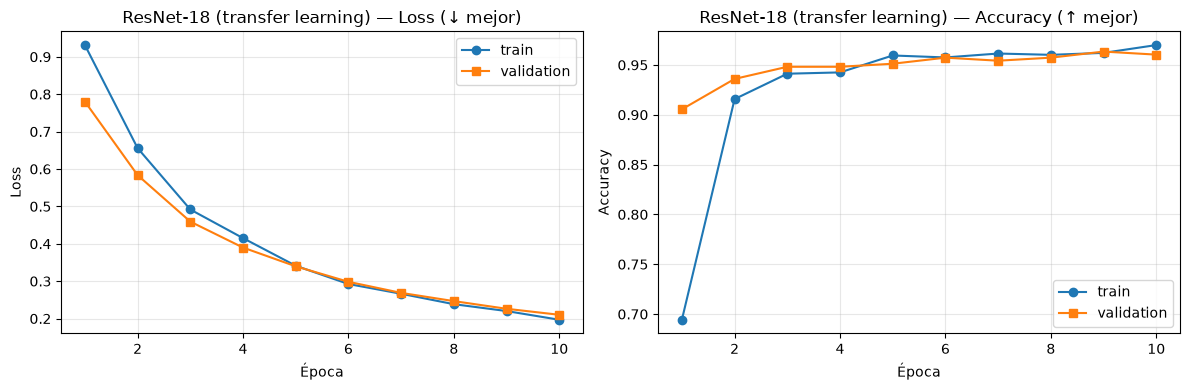

In [51]:
# Solo optimizamos los parámetros descongelados
optimizador_tl = torch.optim.Adam(
    (p for p in modelo_tl.parameters() if p.requires_grad), lr=1e-3
)

# Con transfer learning bastan pocas épocas
historial_tl = fit(modelo_tl, train_dl_tl, val_dl_tl, criterio, optimizador_tl, epocas=10)
graficar_historial(historial_tl, "ResNet-18 (transfer learning)")

### Bonus (opcional): fine-tuning completo

Si hay tiempo: en lugar de entrenar solo la última capa, podemos **descongelar toda la red** y ajustarla completa con un learning rate muy pequeño (`1e-5`), para no destruir lo que ya sabe. A esto se le llama **fine-tuning**.


In [56]:
# Descargamos ResNet-18 pre-entrenada, con capa final nueva de 3 clases
modelo_tl = timm.create_model("resnet18", pretrained=True, num_classes=3).to(DEVICE)


# Descongelamos todo y ajustamos con pasos muy pequeños
for parametro in modelo_tl.parameters():
    parametro.requires_grad = True

optimizador_ft = torch.optim.Adam(modelo_tl.parameters(), lr=1e-5)
historial_ft = fit(modelo_tl, train_dl_tl, val_dl_tl, criterio, optimizador_ft, epocas=20)

Época 1/20 | train loss: 1.0822, acc: 39.78% | val loss: 1.0505, acc: 53.05%
Época 2/20 | train loss: 1.0267, acc: 53.17% | val loss: 0.9961, acc: 60.98%
Época 3/20 | train loss: 0.9676, acc: 64.73% | val loss: 0.9402, acc: 69.51%
Época 4/20 | train loss: 0.9101, acc: 74.92% | val loss: 0.8794, acc: 80.18%
Época 5/20 | train loss: 0.8494, acc: 83.74% | val loss: 0.8157, acc: 86.28%
Época 6/20 | train loss: 0.7817, acc: 89.55% | val loss: 0.7497, acc: 91.77%
Época 7/20 | train loss: 0.7180, acc: 92.62% | val loss: 0.6771, acc: 93.90%
Época 8/20 | train loss: 0.6440, acc: 94.51% | val loss: 0.6066, acc: 94.51%
Época 9/20 | train loss: 0.5689, acc: 95.89% | val loss: 0.5348, acc: 96.34%
Época 10/20 | train loss: 0.5002, acc: 96.21% | val loss: 0.4644, acc: 97.56%
Época 11/20 | train loss: 0.4395, acc: 97.26% | val loss: 0.4013, acc: 97.56%
Época 12/20 | train loss: 0.3829, acc: 97.45% | val loss: 0.3492, acc: 97.56%
Época 13/20 | train loss: 0.3293, acc: 97.98% | val loss: 0.3029, acc: 97

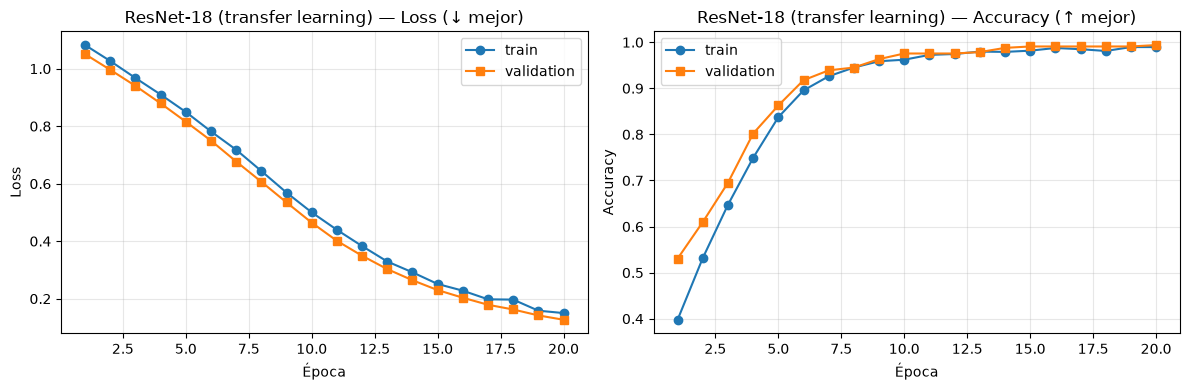

In [57]:
graficar_historial(historial_ft, "ResNet-18 (transfer learning)")

## Evaluación final: el examen con el test set

Momento de la verdad: evaluamos los 3 modelos con las imágenes de **test**, que ninguno vio durante el entrenamiento. Usaremos scikit-learn para:

- **Accuracy**: % de aciertos.
- **Matriz de confusión**: ¿*en qué* se equivoca cada modelo? (p. ej., ¿confunde piedra con tijeras?)
- **Classification report**: precisión y recall por clase.


In [58]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)


@torch.no_grad()
def obtener_predicciones(modelo, dataloader):
    """Devuelve (etiquetas reales, etiquetas predichas) de todo un dataloader."""
    modelo.eval()
    y_real, y_pred = [], []
    for imagenes, etiquetas in dataloader:
        logits = modelo(imagenes.to(DEVICE))
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
        y_real.extend(etiquetas.tolist())
    return y_real, y_pred


modelos_finales = [
    ("MLP", modelo_mlp, test_dl_mlp),
    ("LeNet-5", modelo_lenet, test_dl_cnn),
    ("ResNet-18 (TL)", modelo_tl, test_dl_tl),
]

resultados = {}
predicciones = {}
for nombre, modelo, test_dl in modelos_finales:
    y_real, y_pred = obtener_predicciones(modelo, test_dl)
    predicciones[nombre] = (y_real, y_pred)
    resultados[nombre] = accuracy_score(y_real, y_pred)
    print(f"{nombre:>15s} → accuracy en test: {resultados[nombre]:.2%}")


            MLP → accuracy en test: 96.05%
        LeNet-5 → accuracy en test: 99.39%
 ResNet-18 (TL) → accuracy en test: 99.39%


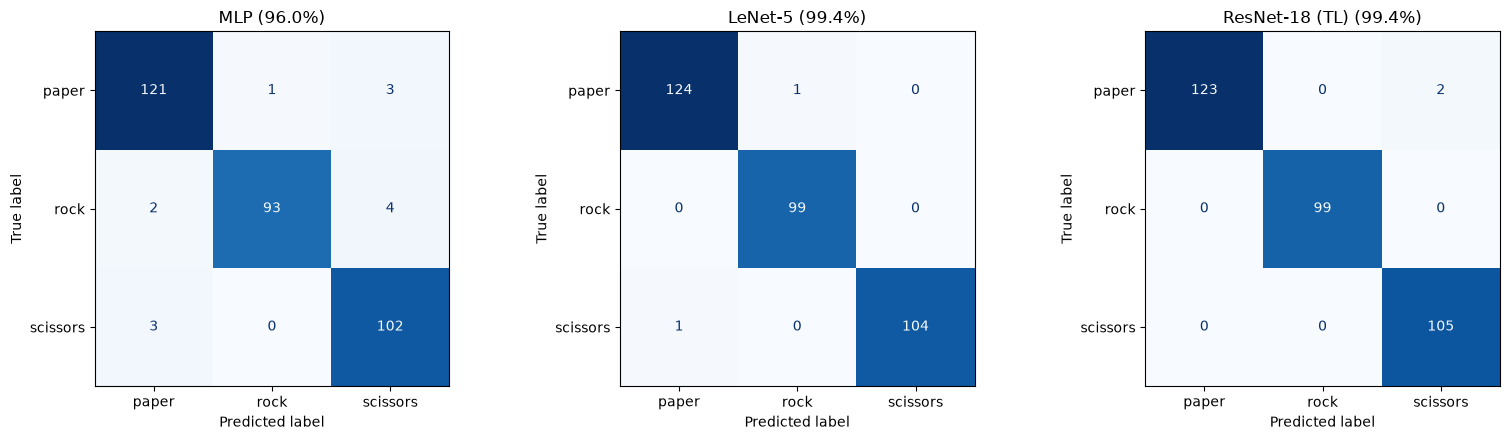

In [59]:
# Matriz de confusión: filas = clase real, columnas = clase predicha
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, (y_real, y_pred)) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred, display_labels=CLASES, ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{nombre} ({resultados[nombre]:.1%})")
plt.tight_layout()
plt.show()


In [61]:
resultados

{'MLP': 0.9604863221884499,
 'LeNet-5': 0.993920972644377,
 'ResNet-18 (TL)': 0.993920972644377}

In [60]:
# Reporte detallado del mejor modelo
mejor_nombre = max(resultados, key=resultados.get)
y_real, y_pred = predicciones[mejor_nombre]

print(f"📊 Classification report — {mejor_nombre}\n")
print(classification_report(y_real, y_pred, target_names=CLASES))


📊 Classification report — LeNet-5

              precision    recall  f1-score   support

       paper       0.99      0.99      0.99       125
        rock       0.99      1.00      0.99        99
    scissors       1.00      0.99      1.00       105

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329



In [62]:
# Reporte detallado del mejor modelo
mejor_nombre = 'ResNet-18 (TL)'
y_real, y_pred = predicciones[mejor_nombre]

print(f"📊 Classification report — {mejor_nombre}\n")
print(classification_report(y_real, y_pred, target_names=CLASES))


📊 Classification report — ResNet-18 (TL)

              precision    recall  f1-score   support

       paper       1.00      0.98      0.99       125
        rock       1.00      1.00      1.00        99
    scissors       0.98      1.00      0.99       105

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329



/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129704 (\N{ROCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


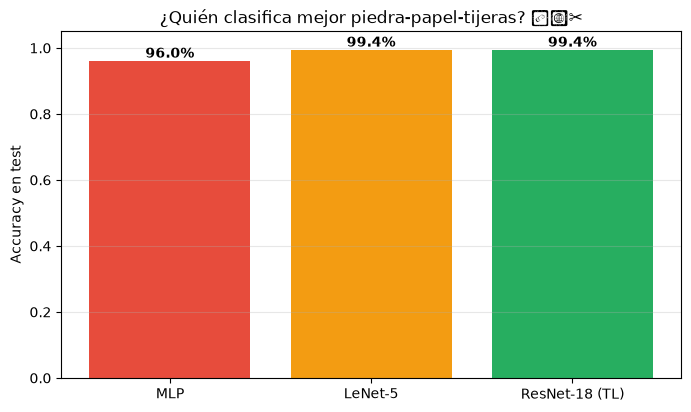

In [63]:
# Comparación visual de los 3 modelos
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(resultados.keys(), resultados.values(),
                color=["#e74c3c", "#f39c12", "#27ae60"])
ax.bar_label(barras, fmt=lambda v: f"{v:.1%}", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy en test")
ax.set_title("¿Quién clasifica mejor piedra-papel-tijeras? 🪨📄✂️")
ax.grid(axis="y", alpha=0.3)
plt.show()


## Pruébalo tú: predice una imagen cualquiera

Cerramos el círculo: una función que recibe **una imagen** y devuelve la predicción con su nivel de confianza. Esto es exactamente lo que haría tu modelo en producción (en una app, una API, etc.).


In [80]:
def crear_dataloaders(transform, batch_size=BATCH_SIZE):
    """Crea los DataLoaders de train/val/test con un transform dado.

    Usamos siempre la misma semilla, así los 3 modelos se evalúan
    exactamente con las mismas imágenes de test (comparación justa).
    """
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    generador = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test], generator=generador
    )

    test_data_imgs = [Path(dataset.imgs[x][0]) for x in test_ds.indices]

    # print(test_data_imgs)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    test_dl = DataLoader(test_ds, batch_size=batch_size)
    return train_dl, val_dl, test_dl, dataset.classes, test_data_imgs


train_dl_cnn, val_dl_cnn, test_dl_cnn, _, test_paths  = crear_dataloaders(transform_cnn)

In [76]:
len(test_paths)

329

In [81]:
test_paths[0]

PosixPath('/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/rock-paper-scissors/scissors/3n4i3lKB3nZOpDVv.png')

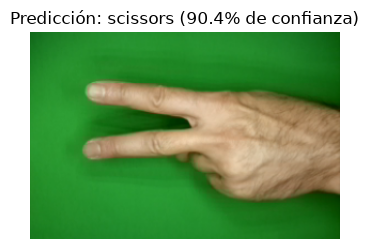

       paper: 5.5%
        rock: 4.1%
    scissors: 90.4%


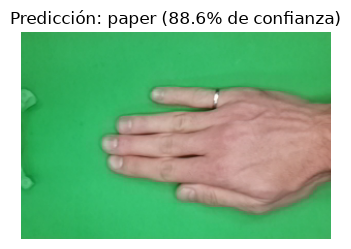

       paper: 88.6%
        rock: 5.3%
    scissors: 6.1%


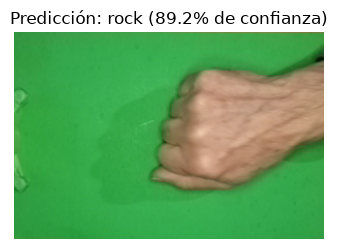

       paper: 6.2%
        rock: 89.2%
    scissors: 4.6%


In [88]:
@torch.no_grad()
def predecir(ruta_imagen, modelo=modelo_tl, transform=transform_tl):
    """Clasifica una imagen y la muestra junto a la predicción."""
    modelo.eval()
    imagen = Image.open(ruta_imagen).convert("RGB")

    tensor = transform(imagen).unsqueeze(0).to(DEVICE)   # añadimos dimensión de batch
    probabilidades = torch.softmax(modelo(tensor), dim=1)[0]
    prediccion = probabilidades.argmax().item()

    plt.figure(figsize=(4, 3.5))
    plt.imshow(imagen)
    plt.axis("off")
    plt.title(f"Predicción: {CLASES[prediccion]} "
              f"({probabilidades[prediccion]:.1%} de confianza)")
    plt.show()

    for clase, prob in zip(CLASES, probabilidades):
        print(f"  {clase:>10s}: {prob:.1%}")


# Probemos con una imagen de cada clase
# predecir(sorted((DATA_DIR / "rock").glob("*.png"))[43])
# predecir(sorted((DATA_DIR / "paper").glob("*.png"))[43])
# predecir(sorted((DATA_DIR / "scissors").glob("*.png"))[43])

random.shuffle(test_paths)
predecir(test_paths[0])
predecir(test_paths[1])
predecir(test_paths[2])

## Guardar los modelos entrenados

Todo lo aprendido por una red vive en sus **pesos** (`state_dict`). Si no los guardamos, al cerrar el notebook el entrenamiento se pierde. La convención en PyTorch es guardar solo los pesos (no el objeto completo) en un archivo `.pt`.


In [89]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Guardamos solo los pesos (state_dict), la práctica recomendada en PyTorch
torch.save(modelo_lenet.state_dict(), MODELS_DIR / "lenet5_rps.pt")
torch.save(modelo_tl.state_dict(), MODELS_DIR / "resnet18_rps.pt")

for archivo in sorted(MODELS_DIR.glob("*.pt")):
    tamano_mb = archivo.stat().st_size / 1024**2
    print(f"✅ {archivo.name} ({tamano_mb:.1f} MB)")

✅ lenet5_rps.pt (0.2 MB)
✅ resnet18_rps.pt (42.7 MB)


In [93]:
# ¿Y cómo los recupero después? 1) crear la arquitectura, 2) cargar los pesos
lenet_cargada = LeNet5()
lenet_cargada.load_state_dict(
    torch.load(MODELS_DIR / "lenet5_rps.pt", map_location=DEVICE)
)
lenet_cargada.to(DEVICE).eval()

resnet_cargada = timm.create_model("resnet18", pretrained=True, num_classes=3)
resnet_cargada.load_state_dict(
    torch.load(MODELS_DIR / "resnet18_rps.pt", map_location=DEVICE)
)
resnet_cargada.to(DEVICE).eval()

# Comprobamos que el modelo cargado predice igual que el original
y_real, y_pred = obtener_predicciones(resnet_cargada, test_dl_tl)
from sklearn.metrics import accuracy_score
print(f"Accuracy de la ResNet-18 cargada desde disco: {accuracy_score(y_real, y_pred):.2%}")


Accuracy de la ResNet-18 cargada desde disco: 99.39%


## Cierre: ¿qué aprendimos?

| | MLP | LeNet-5 (CNN) | ResNet-18 (TL) |
|---|---|---|---|
| **Idea** | Aplana la imagen | Filtros que ven patrones locales | Reutiliza una red experta |
| **Entrada** | 64×64 | 32×32 | 224×224 |
| **Parámetros** | ~6.4M | ~63K | 11.2M (entrena ~0.01%) |
| **Conocimiento previo** | Ninguno | Ninguno | 1.2M imágenes de ImageNet |

**Las 3 lecciones clave:**

1. **El pipeline es siempre el mismo**: datos → preprocesamiento → dataloader → modelo → loss → optimizer → entrenar → evaluar. Cambia el modelo, el resto se reutiliza.
2. **Las CNN superan a los MLP en imágenes** porque respetan la estructura espacial (y con muchos menos parámetros).
3. **En la práctica casi nunca entrenas desde cero**: el transfer learning da mejores resultados, con menos datos y menos tiempo.

